# HT vs. MT Binary Classifier — Softcatalà Spanish-Catalan Corpus

## Overview

Train a binary classifier (`PlanTL-GOB-ES/roberta-base-ca`) to distinguish:
- **Label 1 = HT** — human translation (`.ca` column from the Softcatalà corpus)
- **Label 0 = MT** — machine translation of the same Spanish source

## Training corpora (Softcatalà parallel corpus)
| Corpus | Domain |
|--------|--------|
| TildeMODEL | General |
| DOGC | Official / Legal |
| Europarl | Parliamentary |


## MT systems used for negative examples
| System | Share |
|--------|-------|
| Helsinki-NLP/opus-mt-es-ca | 50 % |
| facebook/nllb-200-distilled-600M | 50 % |

## External test set
`gplsi/ES-VA_translation_test` on Hugging Face — **never seen during training**.

## Classifier output
`translationese_reward(texts) → P(HT) ∈ [0, 1]`  
Used as reward component `r_t` in the GRPO fine-tuning pipeline.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. Install Dependencies

In [1]:
%%capture
!pip install -q transformers datasets evaluate accelerate sentencepiece ctranslate2 scikit-learn seaborn

---
## 2. Download Softcatalà Spanish-Catalan Corpus

The repository https://github.com/Softcatala/parallel-catalan-corpus contains
`.xz`-compressed aligned Spanish-Catalan sentence pairs.
We download four sub-corpora and decompress them.

In [ ]:
import subprocess
import os

BASE_URL = "https://github.com/Softcatala/parallel-catalan-corpus/raw/master/spa-cat/"

CORPORA = [
    "TildeMODEL.es-ca",
    "dogc-es-ca",
    "europarl.es-ca",
]

os.makedirs("data/raw", exist_ok=True)

for corpus in CORPORA:
    for lang in ["es", "ca"]:
        fname = f"{corpus}.{lang}"
        for ext in [".xz", ""]:
            url = BASE_URL + fname + ext
            out = f"data/raw/{fname}{ext}"
            if not os.path.exists(out.replace(".xz", "")):
                r = subprocess.run(["wget", "-q", "-O", out, url])
                if r.returncode == 0 and ext == ".xz":
                    subprocess.run(["xz", "-d", out])
                    print(f"Downloaded and decompressed: {fname}")
                elif r.returncode == 0:
                    print(f"Downloaded: {fname}")
                break

print("\nFiles in data/raw/:")
!ls data/raw/

Downloaded and decompressed: TildeMODEL.es-ca.es
Downloaded and decompressed: TildeMODEL.es-ca.ca
Downloaded and decompressed: dogc-es-ca.es
Downloaded and decompressed: dogc-es-ca.ca
Downloaded and decompressed: europarl.es-ca.es
Downloaded and decompressed: europarl.es-ca.ca

Files in data/raw/:
dogc-es-ca.ca  europarl.es-ca.ca  open-source-es-ca.ca.xz  TildeMODEL.es-ca.ca
dogc-es-ca.es  europarl.es-ca.es  open-source-es-ca.es.xz  TildeMODEL.es-ca.es


---
## 3. Load and Merge Corpora

Read (es, ca) pairs from each sub-corpus, apply basic quality filters,
and sample up to 20,000 pairs per corpus to avoid domain imbalance.

In [3]:
import pandas as pd

frames = []

for corpus in CORPORA:
    es_path = f"data/raw/{corpus}.es"
    ca_path = f"data/raw/{corpus}.ca"
    if os.path.exists(es_path) and os.path.exists(ca_path):
        with open(es_path, encoding="utf-8") as f:
            es_lines = [l.strip() for l in f if l.strip()]
        with open(ca_path, encoding="utf-8") as f:
            ca_lines = [l.strip() for l in f if l.strip()]
        n = min(len(es_lines), len(ca_lines))
        df = pd.DataFrame({
            "source_es": es_lines[:n],
            "ca_human" : ca_lines[:n],
            "corpus"   : corpus,
        })
        frames.append(df)
        print(f"  {corpus}: {n:,} pairs")
    else:
        print(f"  WARNING — not found: {corpus}")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(df_all):,} pairs")
df_all.head()

  TildeMODEL.es-ca: 1,961,358 pairs
  dogc-es-ca: 4,763,575 pairs
  europarl.es-ca: 1,876,668 pairs
  WARNING — not found: open-source-es-ca

Total: 8,601,601 pairs


,source_es,ca_human,corpus
0,"""prestación intracomunitaria de servicios"": to...","""prestació intracomunitària de serveis"": tota ...",TildeMODEL.es-ca
1,“«puesta en circulación» («circulación»): la t...,“«posada en circulació» («circulació»): la tin...,TildeMODEL.es-ca
2,(…) Los interlocutores sociales tienen una imp...,(…) Els interlocutors socials tenen una import...,TildeMODEL.es-ca
3,« - la preparación del proyecto de los estados...,« - la preparació del projecte dels estats de ...,TildeMODEL.es-ca
4,«- la preparación del proyecto del estado de p...,«- la preparació del projecte de l'estat de pr...,TildeMODEL.es-ca


In [ ]:
# Quality filters: remove very short or very long segments
df_all = df_all[
    (df_all.source_es.str.len() > 20) &
    (df_all.ca_human.str.len()  > 20) &
    (df_all.source_es.str.len() < 500) &
    (df_all.ca_human.str.len()  < 500)
]

# Balanced sampling: max 20k per corpus to avoid system bias
MAX_PER_CORPUS = 20_000
df_balanced = (
    df_all.groupby("corpus", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_PER_CORPUS), random_state=42))
    .reset_index(drop=True)
)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset after filtering and sampling: {len(df_balanced):,} pairs")
print(df_balanced.corpus.value_counts())

Dataset after filtering and sampling: 60,000 pairs
corpus
TildeMODEL.es-ca    20000
dogc-es-ca          20000
europarl.es-ca      20000
Name: count, dtype: int64


/tmp/ipykernel_451/4265835624.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_PER_CORPUS), random_state=42))


---
## 4. Generate MT Negative Examples (Helsinki-NLP + NLLB)

## 4. Generate MT Examples (negative)

Each Spanish source is translated by one of two MT systems (assigned randomly, 50/50).
Using two systems increases variety and prevents the classifier from
learning artifacts specific to a single MT engine.

| System | Type |
|--------|------|
| `Helsinki-NLP/opus-mt-es-ca` | Marian (lightweight) |
| `facebook/nllb-200-distilled-600M` | NLLB multilingual |

In [ ]:
import torch

DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if DEVICE == 0 else 'CPU'}")

Device: GPU


In [ ]:
from transformers import MarianMTModel, MarianTokenizer

print("Loading Helsinki-NLP/opus-mt-es-ca...")
HELSINKI_MODEL    = "Helsinki-NLP/opus-mt-es-ca"
helsinki_tok      = MarianTokenizer.from_pretrained(HELSINKI_MODEL)
helsinki_model    = MarianMTModel.from_pretrained(HELSINKI_MODEL)
if DEVICE == 0:
    helsinki_model = helsinki_model.cuda()
helsinki_model.eval()
print("Helsinki model ready")

print("\nLoading facebook/nllb-200-distilled-600M...")
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

NLLB_MODEL   = "facebook/nllb-200-distilled-600M"
nllb_tok     = AutoTokenizer.from_pretrained(NLLB_MODEL)
nllb_model   = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL)
if DEVICE == 0:
    nllb_model = nllb_model.cuda()
nllb_model.eval()

CAT_TOKEN_ID = nllb_tok.convert_tokens_to_ids("cat_Latn")
print(f"NLLB model ready — cat_Latn token id: {CAT_TOKEN_ID}")

Loading Helsinki-NLP/opus-mt-es-ca...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/828k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/823k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

NLLB model ready — cat_Latn token id: 256034


In [ ]:
import numpy as np
from tqdm.auto import tqdm


@torch.no_grad()
def batch_translate_helsinki(texts: list, batch_size: int = 64) -> list:
    """Translate ES → CA using Helsinki MarianMT."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Helsinki"):
        batch = texts[i : i + batch_size]
        tok   = helsinki_tok(batch, return_tensors="pt", padding=True,
                             truncation=True, max_length=256)
        if DEVICE == 0:
            tok = {k: v.cuda() for k, v in tok.items()}
        out = helsinki_model.generate(**tok, max_length=256)
        results.extend(helsinki_tok.batch_decode(out, skip_special_tokens=True))
    return results


@torch.no_grad()
def batch_translate_nllb(texts: list, batch_size: int = 32) -> list:
    """Translate ES → CA using NLLB-200 (spa_Latn → cat_Latn)."""
    results = []
    nllb_tok.src_lang = "spa_Latn"
    for i in tqdm(range(0, len(texts), batch_size), desc="NLLB"):
        batch = texts[i : i + batch_size]
        tok   = nllb_tok(batch, return_tensors="pt", padding=True,
                         truncation=True, max_length=256)
        if DEVICE == 0:
            tok = {k: v.cuda() for k, v in tok.items()}
        out = nllb_model.generate(**tok, forced_bos_token_id=CAT_TOKEN_ID, max_length=256)
        results.extend(nllb_tok.batch_decode(out, skip_special_tokens=True))
    return results

In [ ]:
# Randomly assign each sentence to one MT system (50/50)
np.random.seed(42)
assignment = np.random.choice(["Helsinki", "NLLB"], size=len(df_balanced), p=[0.5, 0.5])

helsinki_idx = np.where(assignment == "Helsinki")[0]
nllb_idx     = np.where(assignment == "NLLB")[0]

mt_translations = [""] * len(df_balanced)

print("Translating with Helsinki...")
helsinki_texts   = df_balanced.iloc[helsinki_idx]["source_es"].tolist()
helsinki_results = batch_translate_helsinki(helsinki_texts, batch_size=64)
for i, t in zip(helsinki_idx, helsinki_results):
    mt_translations[i] = t

print("\nTranslating with NLLB...")
nllb_texts   = df_balanced.iloc[nllb_idx]["source_es"].tolist()
nllb_results = batch_translate_nllb(nllb_texts, batch_size=32)
for i, t in zip(nllb_idx, nllb_results):
    mt_translations[i] = t

df_balanced["ca_mt"]     = mt_translations
df_balanced["mt_system"] = assignment.tolist()

print("\nMT translation complete")
df_balanced[["source_es", "ca_human", "ca_mt", "mt_system"]].head(3)

In [ ]:
# Save intermediate dataset
df_balanced.to_csv("df_balanced_mt_ht.csv", index=False)
# Free MT model memory before classifier training
import gc
del helsinki_model, helsinki_tok, nllb_model, nllb_tok
torch.cuda.empty_cache()
gc.collect()


---
## 5. Build HT vs. MT Classification Dataset

Each source sentence yields **one HT example** and **one MT example**.
The classifier sees only the **target-language text** (no Spanish source),
mirroring inference conditions in the GRPO reward pipeline.

| `text` | `label` |
|--------|---------|
| Human translation (`.ca_human`) | 1 |
| Machine translation (`.ca_mt`) | 0 |

In [19]:
import pandas as pd

PATH = "/content/drive/MyDrive/MsC UPV 26-27/Deep Learning/projectDL/gemma/ht_vs_mt/df_balanced_mt_ht.csv"

df_balanced = pd.read_csv(PATH, sep=',', on_bad_lines='skip')

print("Columns:", df_balanced.columns.tolist())
display(df_balanced.head(3))

Columns: ['source_es', 'ca_human', 'corpus', 'ca_mt', 'mt_system']


,source_es,ca_human,corpus,ca_mt,mt_system
0,El mercado bursátil puede contribuir de manera...,El mercat borsari pot contribuir de manera imp...,TildeMODEL.es-ca,El mercat borsari pot contribuir de manera imp...,Helsinki
1,Se permiten sólo los siguientes usos: en plant...,Es permeten només els usos següents: en plante...,dogc-es-ca,Només es permeten les següents aplicacions: en...,NLLB
2,Es necesario que un mínimo del 5 % del importe...,Cal que un mínim del 5 % de l'import del press...,dogc-es-ca,És necessari que un mínim del 5% de l'import d...,NLLB


In [20]:
# HT rows (label = 1)
ht_rows = df_balanced[["ca_human", "corpus"]].copy()
ht_rows.columns = ["text", "corpus"]
ht_rows["label"]  = 1
ht_rows["source"] = "human"

# MT rows (label = 0)
mt_rows = df_balanced[["ca_mt", "corpus", "mt_system"]].copy()
mt_rows.columns = ["text", "corpus", "source"]
mt_rows["label"]  = 0

df_clf = pd.concat([ht_rows, mt_rows], ignore_index=True)
df_clf = df_clf.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Classifier dataset: {len(df_clf):,} examples")
print(df_clf.label.value_counts())
df_clf.head(4)

Classifier dataset: 120,000 examples
label
0    60000
1    60000
Name: count, dtype: int64


,text,corpus,label,source
0,Això significa que hem creat un instrument a l...,europarl.es-ca,0,NLLB
1,El disseny i la implementació de nous instrume...,TildeMODEL.es-ca,0,NLLB
2,La majoria de les empreses consideren que el r...,TildeMODEL.es-ca,1,human
3,Crec que és fonamental el que s'hagi previst l...,europarl.es-ca,1,human


In [24]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

os.makedirs("data", exist_ok=True)

train_df, val_df = train_test_split(
    df_clf, test_size=0.1, stratify=df_clf["label"], random_state=42
)

train_ds = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True))

print(f"Train: {len(train_ds):,} | Validation: {len(val_ds):,}")

# Save splits
train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/val.csv", index=False)
df_clf.to_parquet("data/ht_mt_classifier_dataset.parquet", index=False)
print("Saved → data/train.csv, data/val.csv, data/ht_mt_classifier_dataset.parquet")

Train: 108,000 | Validation: 12,000


---
## 6. Tokenization with `roberta-base-ca`

In [25]:
from transformers import AutoTokenizer

MODEL_NAME = "PlanTL-GOB-ES/roberta-base-ca"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    encoded = tokenizer(
        batch["text"],
        truncation    = True,
        max_length    = 128,
        padding       = "max_length",
    )
    encoded["labels"] = batch["label"]
    return encoded


train_tok = train_ds.map(tokenize, batched=True, remove_columns=["text", "label"])
val_tok   = val_ds.map(tokenize,   batched=True, remove_columns=["text", "label"])

train_tok.set_format("torch")
val_tok.set_format("torch")

print("Tokenization complete")
print("Features:", train_tok.features)

config.json:   0%|          | 0.00/516 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Tokenization complete
Features: {'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': Value('int64')}


---
## 7. Train the Classifier

In [26]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
import evaluate
import json

clf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = 2,
    id2label   = {0: "MT", 1: "HT"},
    label2id   = {"MT": 0, "HT": 1},
)

accuracy_metric  = evaluate.load("accuracy")
f1_metric        = evaluate.load("f1")
recall_metric    = evaluate.load("recall")
precision_metric = evaluate.load("precision")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        **accuracy_metric.compute(predictions=predictions, references=labels),
        **f1_metric.compute(predictions=predictions, references=labels, average="macro"),
        **recall_metric.compute(predictions=predictions, references=labels, average="macro"),
        **precision_metric.compute(predictions=predictions, references=labels, average="macro"),
    }

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: PlanTL-GOB-ES/roberta-base-ca
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

In [27]:
class VerboseCallback(TrainerCallback):
    """Prints training/eval metrics to stdout and saves eval history to JSON."""

    def __init__(self, tokenizer, val_dataset):
        self.tokenizer   = tokenizer
        self.val_dataset = val_dataset

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        step  = state.global_step
        epoch = state.epoch or 0

        if "loss" in logs:
            print(f"  step {step:>5} | epoch {epoch:.2f} | train_loss: {logs['loss']:.4f}")

        if "eval_loss" in logs:
            print("\n" + "="*60)
            print(f"  EVAL — epoch {epoch:.0f}  (step {step})")
            print(f"  {'loss':<12} {logs.get('eval_loss', 0):.4f}")
            print(f"  {'accuracy':<12} {logs.get('eval_accuracy', 0):.4f}")
            print(f"  {'f1-macro':<12} {logs.get('eval_f1', 0):.4f}")
            print(f"  {'precision':<12} {logs.get('eval_precision', 0):.4f}")
            print(f"  {'recall':<12} {logs.get('eval_recall', 0):.4f}")
            print("="*60 + "\n")

            # Persist eval history
            history_path = os.path.join(args.output_dir, "training_history.json")
            history = json.load(open(history_path)) if os.path.exists(history_path) else []
            history.append({k: v for k, v in logs.items()})
            with open(history_path, "w") as f:
                json.dump(history, f, indent=2)

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        """Print 3 qualitative examples from the validation set after each epoch."""
        if model is None:
            return
        model.eval()
        label_map = {0: "MT", 1: "HT"}
        print("\n── 3 validation examples ──")
        for i in range(3):
            sample = self.val_dataset[i]
            ids    = sample["input_ids"].unsqueeze(0).to(model.device)
            mask   = sample["attention_mask"].unsqueeze(0).to(model.device)
            real   = label_map[sample["labels"].item()]
            with torch.no_grad():
                logits = model(input_ids=ids, attention_mask=mask).logits
            pred = label_map[logits.argmax(-1).item()]
            icon = "OK" if real == pred else "WRONG"
            text = self.tokenizer.decode(sample["input_ids"], skip_special_tokens=True)[:90]
            print(f"  [{icon}] real={real} pred={pred} | \"{text}...\"")
        print()

In [33]:
class LossPlotCallback(TrainerCallback):
    def __init__(self, save_path="classifier_loss.png"):
        self.save_path    = save_path
        self.train_steps  = []
        self.train_losses = []
        self.eval_steps   = []
        self.eval_losses  = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        if "loss" in logs:
            self.train_steps.append(state.global_step)
            self.train_losses.append(logs["loss"])
        if "eval_loss" in logs:
            self.eval_steps.append(state.global_step)
            self.eval_losses.append(logs["eval_loss"])
        self._save_plot()

    def _save_plot(self):
        fig, ax = plt.subplots(figsize=(10, 4))
        if self.train_losses:
            ax.plot(self.train_steps, self.train_losses,
                    label="Train loss", color="#2B5797", linewidth=1.5)
        if self.eval_losses:
            ax.plot(self.eval_steps, self.eval_losses,
                    label="Val loss", color="#E05C2A",
                    linewidth=2, linestyle="--", marker="o", markersize=6)
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.set_title("HT vs MT Classifier -- Training Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(self.save_path, dpi=150, bbox_inches="tight")
        plt.close()

In [34]:
os.makedirs("./ht_mt_classifier", exist_ok=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir                  = "./ht_mt_classifier",
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 32,
    warmup_ratio                = 0.06,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = torch.cuda.is_available(),
    report_to                   = "none",
)

trainer = Trainer(
    model         = clf_model,
    args          = training_args,
    train_dataset = train_tok,
    eval_dataset  = val_tok,
    data_collator = data_collator,
    compute_metrics = compute_metrics,
    callbacks     = [
        LossPlotCallback("classifier_loss.png"),
        VerboseCallback(tokenizer=tokenizer, val_dataset=val_tok),
        EarlyStoppingCallback(early_stopping_patience=4),
    ],
)



warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [35]:
print("Starting training...")
trainer.train()

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Recall,Precision
1,0.304368,0.564892,0.738583,0.736323,0.738583,0.747054
2,0.387131,0.471168,0.747333,0.745973,0.747333,0.752745
3,0.324835,0.515748,0.729833,0.729598,0.729833,0.730636
4,0.317087,0.580683,0.723583,0.723262,0.723583,0.724627
5,0.260361,0.696992,0.715333,0.714936,0.715333,0.716541


  step    50 | epoch 0.01 | train_loss: 0.4865
  step   100 | epoch 0.03 | train_loss: 0.4506
  step   150 | epoch 0.04 | train_loss: 0.4459
  step   200 | epoch 0.06 | train_loss: 0.4292
  step   250 | epoch 0.07 | train_loss: 0.4240
  step   300 | epoch 0.09 | train_loss: 0.4025
  step   350 | epoch 0.10 | train_loss: 0.4010
  step   400 | epoch 0.12 | train_loss: 0.3692
  step   450 | epoch 0.13 | train_loss: 0.3775
  step   500 | epoch 0.15 | train_loss: 0.3410
  step   550 | epoch 0.16 | train_loss: 0.3091
  step   600 | epoch 0.18 | train_loss: 0.3214
  step   650 | epoch 0.19 | train_loss: 0.2963
  step   700 | epoch 0.21 | train_loss: 0.2718
  step   750 | epoch 0.22 | train_loss: 0.2421
  step   800 | epoch 0.24 | train_loss: 0.2503
  step   850 | epoch 0.25 | train_loss: 0.2156
  step   900 | epoch 0.27 | train_loss: 0.1524
  step   950 | epoch 0.28 | train_loss: 0.2787
  step  1000 | epoch 0.30 | train_loss: 0.3060
  step  1050 | epoch 0.31 | train_loss: 0.3241
  step  1100 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  step  3400 | epoch 1.01 | train_loss: 0.2702
  step  3450 | epoch 1.02 | train_loss: 0.2142
  step  3500 | epoch 1.04 | train_loss: 0.2110
  step  3550 | epoch 1.05 | train_loss: 0.2456
  step  3600 | epoch 1.07 | train_loss: 0.2339
  step  3650 | epoch 1.08 | train_loss: 0.2067
  step  3700 | epoch 1.10 | train_loss: 0.2317
  step  3750 | epoch 1.11 | train_loss: 0.2352
  step  3800 | epoch 1.13 | train_loss: 0.2407
  step  3850 | epoch 1.14 | train_loss: 0.4239
  step  3900 | epoch 1.16 | train_loss: 0.3724
  step  3950 | epoch 1.17 | train_loss: 0.3920
  step  4000 | epoch 1.19 | train_loss: 0.3895
  step  4050 | epoch 1.20 | train_loss: 0.3619
  step  4100 | epoch 1.21 | train_loss: 0.3792
  step  4150 | epoch 1.23 | train_loss: 0.3834
  step  4200 | epoch 1.24 | train_loss: 0.3833
  step  4250 | epoch 1.26 | train_loss: 0.4009
  step  4300 | epoch 1.27 | train_loss: 0.3952
  step  4350 | epoch 1.29 | train_loss: 0.3872
  step  4400 | epoch 1.30 | train_loss: 0.3970
  step  4450 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  step 13550 | epoch 4.01 | train_loss: 0.2603
  step 13600 | epoch 4.03 | train_loss: 0.2512
  step 13650 | epoch 4.04 | train_loss: 0.2612
  step 13700 | epoch 4.06 | train_loss: 0.2701
  step 13750 | epoch 4.07 | train_loss: 0.2408
  step 13800 | epoch 4.09 | train_loss: 0.2462
  step 13850 | epoch 4.10 | train_loss: 0.2673
  step 13900 | epoch 4.12 | train_loss: 0.2491
  step 13950 | epoch 4.13 | train_loss: 0.2453
  step 14000 | epoch 4.15 | train_loss: 0.2581
  step 14050 | epoch 4.16 | train_loss: 0.2556
  step 14100 | epoch 4.18 | train_loss: 0.2254
  step 14150 | epoch 4.19 | train_loss: 0.2829
  step 14200 | epoch 4.21 | train_loss: 0.2590
  step 14250 | epoch 4.22 | train_loss: 0.2481
  step 14300 | epoch 4.24 | train_loss: 0.2556
  step 14350 | epoch 4.25 | train_loss: 0.2780
  step 14400 | epoch 4.27 | train_loss: 0.2714
  step 14450 | epoch 4.28 | train_loss: 0.2756
  step 14500 | epoch 4.30 | train_loss: 0.2505
  step 14550 | epoch 4.31 | train_loss: 0.2595
  step 14600 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=16875, training_loss=0.3134215044657389, metrics={'train_runtime': 4482.5777, 'train_samples_per_second': 120.466, 'train_steps_per_second': 3.765, 'total_flos': 3.55199924736e+16, 'train_loss': 0.3134215044657389, 'epoch': 5.0})

In [36]:
# Final evaluation on validation set
results = trainer.evaluate()
print("\nValidation results:")
for k, v in results.items():
    print(f"  {k}: {v:.4f}")


  EVAL — epoch 5  (step 16875)
  loss         0.4737
  accuracy     0.7468
  f1-macro     0.7454
  precision    0.7520
  recall       0.7468


Validation results:
  eval_loss: 0.4737
  eval_accuracy: 0.7468
  eval_f1: 0.7454
  eval_recall: 0.7468
  eval_precision: 0.7520
  eval_runtime: 21.0780
  eval_samples_per_second: 569.3130
  eval_steps_per_second: 17.7910
  epoch: 5.0000


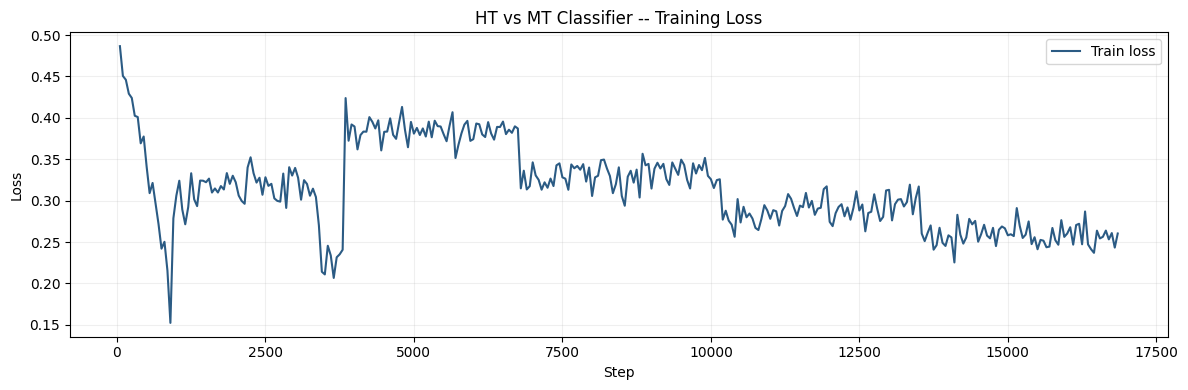

In [40]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
steps = [x['step'] for x in history if 'loss' in x]
train_losses = [x['loss'] for x in history if 'loss' in x]

plt.figure(figsize=(12, 4))
plt.plot(steps, train_losses, label='Train loss', color='#2b5b84', linewidth=1.5)

plt.title('HT vs MT Classifier -- Training Loss', fontsize=12)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, linestyle='-', alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

---
## 8. Save and Push Model to Hugging Face Hub

In [37]:
CLF_OUTPUT_DIR = "./ht_mt_classifier_best"

trainer.save_model(CLF_OUTPUT_DIR)
tokenizer.save_pretrained(CLF_OUTPUT_DIR)
print(f"Model saved to {CLF_OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./ht_mt_classifier_best


In [ ]:
from huggingface_hub import login

login(token="")

trainer.push_to_hub("guerreropaula/ht_mt_classifier_best")
clf_tok.push_to_hub("guerreropaula/ht_mt_classifier_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ssifier/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...ssifier/model.safetensors:   0%|          |  566kB /  504MB            

CommitInfo(commit_url='https://huggingface.co/guerreropaula/2vht_mt_classifier_best/commit/d4797131d623e6b892c2e6ac45946b1b5119ff91', commit_message='Upload tokenizer', commit_description='', oid='d4797131d623e6b892c2e6ac45946b1b5119ff91', pr_url=None, repo_url=RepoUrl('https://huggingface.co/guerreropaula/2vht_mt_classifier_best', endpoint='https://huggingface.co', repo_type='model', repo_id='guerreropaula/2vht_mt_classifier_best'), pr_revision=None, pr_num=None)

---
## 9. External Test Set Evaluation: `gplsi/ES-VA_translation_test`

This dataset contains Spanish-Valencian sentence pairs and is used **only** as
a held-out external test — it was never seen during training.

We build a balanced test set:
- HT examples: the `va` column (human Valencian translations)
- MT examples: NLLB-200 translations of the `es` column

Note: Valencian is a variety of Catalan. Some accuracy degradation relative to
the validation set is expected and normal, since the classifier was trained on
standard Catalan.

In [ ]:
from datasets import load_dataset

test_hf = load_dataset("gplsi/ES-VA_translation_test", split="test")
print("Columns:", test_hf.column_names)
print(f"Examples: {len(test_hf):,}")
print(test_hf[0])

In [ ]:
# Re-load NLLB to generate MT examples for the test set

from transformers import AutoTokenizer as AT, AutoModelForSeq2SeqLM as AMSS

nllb_tok_test   = AT.from_pretrained(NLLB_MODEL)
nllb_model_test = AMSS.from_pretrained(NLLB_MODEL)
if DEVICE == 0:
    nllb_model_test = nllb_model_test.cuda()
nllb_model_test.eval()
CAT_TOKEN_ID_TEST = nllb_tok_test.convert_tokens_to_ids("cat_Latn")
print(f"NLLB ready — cat_Latn token id: {CAT_TOKEN_ID_TEST}")


@torch.no_grad()
def translate_nllb_test(texts: list, batch_size: int = 32) -> list:
    results = []
    nllb_tok_test.src_lang = "spa_Latn"
    for i in tqdm(range(0, len(texts), batch_size), desc="NLLB test"):
        batch = texts[i : i + batch_size]
        tok   = nllb_tok_test(batch, return_tensors="pt", padding=True,
                              truncation=True, max_length=256)
        if DEVICE == 0:
            tok = {k: v.cuda() for k, v in tok.items()}
        out = nllb_model_test.generate(
            **tok, forced_bos_token_id=CAT_TOKEN_ID_TEST, max_length=256
        )
        results.extend(nllb_tok_test.batch_decode(out, skip_special_tokens=True))
    return results


# Build test rows
test_rows = []

# HT examples from 'va' column
for row in test_hf:
    if row.get("va"):
        test_rows.append({"text": row["va"], "label": 1})

# MT examples — translate 'es' column
es_texts   = [row["es"] for row in test_hf if row.get("es")]
mt_results = translate_nllb_test(es_texts, batch_size=32)
for mt_text in mt_results:
    test_rows.append({"text": mt_text, "label": 0})

test_df = pd.DataFrame(test_rows)
print(f"\nTest set: {len(test_df):,} examples")
print(test_df.label.value_counts())

del nllb_model_test, nllb_tok_test
torch.cuda.empty_cache()
gc.collect()
print("NLLB test model removed from memory")

In [ ]:
from transformers import pipeline as hf_pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

clf_pipe = hf_pipeline(
    "text-classification",
    model     = CLF_OUTPUT_DIR,
    tokenizer = CLF_OUTPUT_DIR,
    device    = 0 if torch.cuda.is_available() else -1,
    truncation  = True,
    max_length  = 128,
    batch_size  = 64,
)

predictions_raw = clf_pipe(test_df["text"].tolist())
preds  = [1 if p["label"] == "HT" else 0 for p in predictions_raw]
labels = test_df["label"].tolist()

RESULTADOS EN gplsi/ES-VA_translation_test
              precision    recall  f1-score   support

      MT (0)       0.75      0.75      0.75      1958
      HT (1)       0.75      0.75      0.75      1958

    accuracy                           0.75      3916
   macro avg       0.75      0.75      0.75      3916
weighted avg       0.75      0.75      0.75      3916



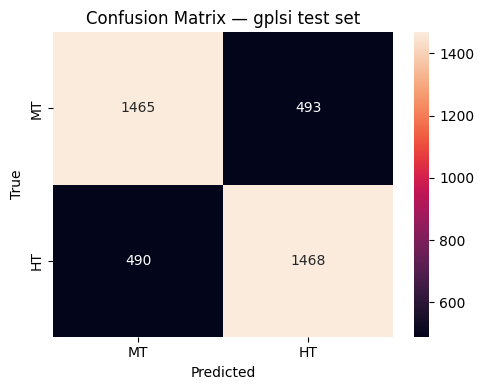

In [ ]:
print("RESULTS ON gplsi/ES-VA_translation_test")

print(classification_report(labels, preds, target_names=["MT (0)", "HT (1)"]))

cm  = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["MT", "HT"], yticklabels=["MT", "HT"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — gplsi/ES-VA_translation_test")
plt.tight_layout()
plt.savefig("confusion_matrix_gplsi.png", dpi=150)
plt.show()
print("Saved → confusion_matrix_gplsi.png")

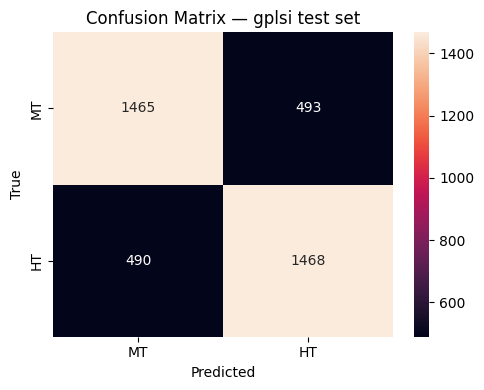

---
## 10. Error Analysis

In [ ]:
test_df["pred"]     = preds
test_df["score_ht"] = [
    p["score"] if p["label"] == "HT" else 1 - p["score"]
    for p in predictions_raw
]

errors = test_df[test_df.label != test_df.pred]
print(f"Errors: {len(errors):,} / {len(test_df):,} ({100 * len(errors) / len(test_df):.1f}%)")

print("\n── False negatives (HT predicted as MT) ──")
print(errors[errors.label == 1].nsmallest(5, "score_ht")[["text", "score_ht"]].to_string())

print("\n── False positives (MT predicted as HT) ──")
print(errors[errors.label == 0].nlargest(5, "score_ht")[["text", "score_ht"]].to_string())

---
## 11. Validation Set Inspection

In [ ]:
def inspect_examples(dataset, n: int = 200, out_file: str = "inspection_examples.csv"):
    """Run inference on the first n examples and save predictions to CSV."""
    label_map = {0: "MT", 1: "HT"}
    texts  = dataset["text"][:n]
    labels = dataset["label"][:n]

    enc = tokenizer(
        texts, return_tensors="pt", truncation=True, padding=True, max_length=128
    )
    if torch.cuda.is_available():
        enc       = {k: v.cuda() for k, v in enc.items()}
        clf_model = clf_model.cuda()

    with torch.no_grad():
        logits   = clf_model(**enc).logits
        probs    = torch.softmax(logits, dim=-1)

    preds_ins    = probs.argmax(-1).cpu().tolist()
    probs_ht_ins = probs[:, 1].cpu().tolist()

    rows = [
        {
            "text"      : texts[i],
            "real_label": label_map[labels[i]],
            "pred_label": label_map[preds_ins[i]],
            "prob_HT"   : round(probs_ht_ins[i], 4),
            "correct"   : labels[i] == preds_ins[i],
        }
        for i in range(len(texts))
    ]

    df_out = pd.DataFrame(rows)
    df_out.to_csv(out_file, index=False)
    print(f"Saved: {out_file}")
    print(df_out.head(10))
    return df_out


inspect_examples(val_ds, n=200)

---
## 12. `translationese_reward` — GRPO Integration

Once trained, the classifier is wrapped in a reward function for use in the
GRPO training loop. The reward is the **probability of class HT** ∈ [0, 1].

Higher values indicate that the generated translation looks more like a
human translation, which is the desired direction for GRPO optimization.

In [ ]:
import torch.nn.functional as F
from transformers import AutoTokenizer as _AT2, AutoModelForSequenceClassification as _AMSC

CLF_REPO_ID  = "guerreropaula/ht_mt_classifier_best"
HT_LABEL_IDX = 1

_clf_tok2   = _AT2.from_pretrained(CLF_REPO_ID)
_clf_model2 = _AMSC.from_pretrained(CLF_REPO_ID).eval()
if torch.cuda.is_available():
    _clf_model2 = _clf_model2.cuda()

@torch.no_grad()
def translationese_reward(texts, batch_size=16):
    """Returns P(HT | text) ∈ [0, 1] for each text. Use as r_t in GRPO."""
    rewards = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = _clf_tok2(batch, return_tensors="pt", padding=True,
                          truncation=True, max_length=256)
        if torch.cuda.is_available():
            enc = {k: v.cuda() for k, v in enc.items()}
        probs = F.softmax(_clf_model2(**enc).logits, dim=-1)
        rewards.extend(probs[:, HT_LABEL_IDX].cpu().tolist())
    return rewards

# Quick test
test_texts = [
    "L'ajuntament ha aprovat el nou pressupost.",
    "The town hall has approved the new budget.",
    "El ayuntamiento ha aprobado el nuevo presupuesto.",
]
scores = translationese_reward(test_texts)
for t, s in zip(test_texts, scores):
    print(f"  P(HT)={s:.3f}  |  {t[:60]}")

---
## Summary

```
Softcatalà spa-cat corpus
│
├── .ca  (human)  ──────────────────────────────────► label = 1  (HT)
│
└── .es  (source) → Helsinki-NLP/opus-mt-es-ca (50%) ► label = 0  (MT)
                  → facebook/nllb-200-600M      (50%) ► label = 0  (MT)

Total: ~80–100k balanced examples
Model: PlanTL-GOB-ES/roberta-base-ca → fine-tuned binary classifier
Test : gplsi/ES-VA_translation_test  (Valencian, held-out)
Output: translationese_reward(texts) → P(HT) ∈ [0, 1]
```

**Design notes:**
- The classifier sees **only the target-language text** (no Spanish source),
  matching the inference conditions in the GRPO reward pipeline.
- Two MT systems (Helsinki + NLLB) are used to prevent the classifier from
  learning artifacts of a single engine.
- The external test set is in **Valencian** (not standard Catalan), so some
  accuracy degradation relative to the validation set is expected.